# 🎬 Netflix User Segmentation — K-Means Clustering & PCA

**Session 3 | Industrial Use Case 1 | DSA & ML for Business**

---

### Business Context
- Netflix has **247M subscribers** across **190 countries**
- Content library costs **$17B/year** — ROI depends on matching content to segments
- Netflix loses **$1.6B/year** to churn (avg subscriber stays 15 months)
- **80% of content watched** comes from algorithmic recommendations

### What You'll Learn
1. **Feature engineering** — encode categorical features for clustering
2. **K-Means clustering** with Elbow & Silhouette validation
3. **PCA visualization** — reduce dimensions for 2D cluster plots
4. **Cluster profiling** — name each segment with business personas
5. **Retention strategy** — connect segments to actionable business decisions

## Step 1: Import Libraries & Load Dataset

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

### Load Dataset & Quick Inspection

In [25]:
df = pd.read_csv("../datasets/netflix_user_segmentation.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nSubscription types: {df['subscription_type'].value_counts().to_dict()}")
print(f"Device types: {df['device_primary'].value_counts().to_dict()}")
print(df.head(10))
df.describe().round(2)

Dataset shape: (3000, 7)
Columns: ['user_id', 'avg_watch_hours', 'genre_diversity_score', 'subscription_type', 'days_active', 'completion_rate', 'device_primary']

Subscription types: {'premium': 1256, 'standard': 791, 'ad_supported': 491, 'basic': 462}
Device types: {'mobile': 884, 'smart_tv': 879, 'desktop': 675, 'tablet': 562}
      user_id  avg_watch_hours  genre_diversity_score subscription_type  \
0  user_00001             6.37                   0.60           premium   
1  user_00002             6.87                   0.67           premium   
2  user_00003             7.47                   0.30           premium   
3  user_00004             6.41                   0.68          standard   
4  user_00005             7.21                   0.65          standard   
5  user_00006             8.18                   0.42           premium   
6  user_00007             0.83                   0.20             basic   
7  user_00008             8.50                   0.48          stand

,avg_watch_hours,genre_diversity_score,days_active,completion_rate
count,3000.00,3000.00,3000.00,3000.00
mean,3.92,0.50,18.77,0.61
std,2.33,0.22,7.41,0.20
min,0.51,0.10,5.00,0.20
25%,1.93,0.33,12.00,0.44
50%,3.48,0.48,20.00,0.64
75%,5.44,0.67,25.00,0.78
max,9.99,1.00,30.00,0.95


## Step 2: Feature Engineering & Scaling

### Why do we need encoding?

K-Means (and most ML algorithms) only understand **numbers**, not text. Our dataset has categorical columns like `subscription_type` ("basic", "premium") and `device_primary` ("mobile", "tv"). We must convert them to numbers.

**Two encoding strategies:**

| Strategy | When to Use | Example |
|----------|------------|---------|
| **Ordinal Encoding** | Categories have a natural order | `ad_supported < basic < standard < premium` → 0, 1, 2, 3 |
| **One-Hot Encoding** | Categories have NO order | `mobile, tv, tablet, laptop` → 4 binary columns |

**What happens if we DON'T encode?**
- K-Means will **crash** — it can't compute distance between "premium" and "basic"
- If we just assign random numbers (e.g., mobile=1, tv=2), the algorithm thinks tv is "bigger" than mobile, introducing **false relationships**

### Example: See the raw categorical data (before encoding)

In [26]:
# Look at the categorical columns — these are text, K-Means can't use them directly
print("=== Subscription Type (has natural order) ===")
print(df['subscription_type'].value_counts())
print(f"\nData type: {df['subscription_type'].dtype}  ← This is text, not a number!")

print("\n=== Device Primary (no natural order) ===")
print(df['device_primary'].value_counts())
print(f"\nData type: {df['device_primary'].dtype}  ← Also text!")

# Show a few rows to see the problem
print("\n=== Sample rows — mix of numbers and text ===")
df[['avg_watch_hours', 'subscription_type', 'device_primary', 'days_active']].head(8)

=== Subscription Type (has natural order) ===
subscription_type
premium         1256
standard         791
ad_supported     491
basic            462
Name: count, dtype: int64

Data type: str  ← This is text, not a number!

=== Device Primary (no natural order) ===
device_primary
mobile      884
smart_tv    879
desktop     675
tablet      562
Name: count, dtype: int64

Data type: str  ← Also text!

=== Sample rows — mix of numbers and text ===


,avg_watch_hours,subscription_type,device_primary,days_active
0,6.37,premium,smart_tv,29
1,6.87,premium,desktop,30
2,7.47,premium,smart_tv,29
3,6.41,standard,desktop,23
4,7.21,standard,smart_tv,22
5,8.18,premium,smart_tv,26
6,0.83,basic,mobile,9
7,8.50,standard,desktop,29


### Ordinal Encoding for Subscription Type

Since `ad_supported < basic < standard < premium` has a **natural hierarchy** (higher plan = more features & cost), we assign ordered numbers:

```
ad_supported → 0,  basic → 1,  standard → 2,  premium → 3
```

### One-Hot Encoding for Device Type

`mobile`, `tv`, `tablet`, `laptop` have **no ranking** — a TV isn't "greater than" a mobile. So we create **binary columns** (0 or 1) for each device:

| Original Value | device_laptop | device_mobile | device_tablet | device_tv |
|----------------|:---:|:---:|:---:|:---:|
| **mobile**     | 0 | **1** | 0 | 0 |
| **tv**         | 0 | 0 | 0 | **1** |
| **tablet**     | 0 | 0 | **1** | 0 |
| **laptop**     | **1** | 0 | 0 | 0 |

Each row has exactly **one 1** and the rest are 0s — that's why it's called "one-hot".

In [27]:
# Encode categorical features
sub_order = {'ad_supported': 0, 'basic': 1, 'standard': 2, 'premium': 3}
df['subscription_encoded'] = df['subscription_type'].map(sub_order)

device_dummies = pd.get_dummies(df['device_primary'], prefix='device')
print("Subscription encoding:", sub_order)
print(f"\nDevice one-hot columns: {list(device_dummies.columns)}")
device_dummies.head()

Subscription encoding: {'ad_supported': 0, 'basic': 1, 'standard': 2, 'premium': 3}

Device one-hot columns: ['device_desktop', 'device_mobile', 'device_smart_tv', 'device_tablet']


,device_desktop,device_mobile,device_smart_tv,device_tablet
0,False,False,True,False
1,True,False,False,False
2,False,False,True,False
3,True,False,False,False
4,False,False,True,False


### Build Feature Matrix

In [28]:
df_features = pd.concat([
    df[['avg_watch_hours', 'genre_diversity_score', 'days_active', 'completion_rate', 'subscription_encoded']],
    device_dummies
], axis=1)

feature_names = df_features.columns.tolist()
print(f"Feature matrix shape: {df_features.shape}")
print(f"Features: {feature_names}")
df_features.head()

Feature matrix shape: (3000, 9)
Features: ['avg_watch_hours', 'genre_diversity_score', 'days_active', 'completion_rate', 'subscription_encoded', 'device_desktop', 'device_mobile', 'device_smart_tv', 'device_tablet']


,avg_watch_hours,genre_diversity_score,days_active,completion_rate,subscription_encoded,device_desktop,device_mobile,device_smart_tv,device_tablet
0,6.37,0.60,29,0.87,3,False,False,True,False
1,6.87,0.67,30,0.62,3,True,False,False,False
2,7.47,0.30,29,0.76,3,False,False,True,False
3,6.41,0.68,23,0.91,2,True,False,False,False
4,7.21,0.65,22,0.78,2,False,False,True,False


### Why do we need Scaling?

K-Means uses **Euclidean distance** to assign points to clusters. If features have different scales, **the feature with the largest range dominates** the distance calculation.

**Example — Without Scaling:**
| Feature | Range | Impact on Distance |
|---------|-------|--------------------|
| `days_active` | 1 – 30 | Dominates! (large numbers) |
| `completion_rate` | 0.0 – 1.0 | Almost ignored (tiny numbers) |

A difference of 10 in `days_active` overpowers a difference of 0.5 in `completion_rate`, even though both might be equally important.

**StandardScaler** transforms each feature to **mean = 0, std = 1**, putting all features on equal footing:
```
scaled_value = (original_value - mean) / std_deviation
```

### Example: See how different the feature ranges are (before scaling)

In [29]:
# Compare ranges BEFORE scaling — notice how different they are!
print("=== Feature Ranges BEFORE Scaling ===\n")
for col in ['avg_watch_hours', 'days_active', 'completion_rate', 'genre_diversity_score', 'subscription_encoded']:
    print(f"  {col:30s} → min: {df_features[col].min():8.2f}  max: {df_features[col].max():8.2f}  range: {df_features[col].max() - df_features[col].min():8.2f}")

print("\n⚠️ days_active ranges 1–30, but completion_rate ranges 0–1")
print("   K-Means would treat days_active as ~30x more important!")

=== Feature Ranges BEFORE Scaling ===

  avg_watch_hours                → min:     0.51  max:     9.99  range:     9.48
  days_active                    → min:     5.00  max:    30.00  range:    25.00
  completion_rate                → min:     0.20  max:     0.95  range:     0.75
  genre_diversity_score          → min:     0.10  max:     1.00  range:     0.90
  subscription_encoded           → min:     0.00  max:     3.00  range:     3.00

⚠️ days_active ranges 1–30, but completion_rate ranges 0–1
   K-Means would treat days_active as ~30x more important!


In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

print(f"Scaled matrix shape: {X_scaled.shape}")
print(f"Mean of first feature (should be ~0): {X_scaled[:, 0].mean():.6f}")
print(f"Std of first feature (should be ~1): {X_scaled[:, 0].std():.6f}")

Scaled matrix shape: (3000, 9)
Mean of first feature (should be ~0): -0.000000
Std of first feature (should be ~1): 1.000000


### ⚠️ What happens if we DON'T scale? (Demo)

Let's run K-Means on the **unscaled** data and compare the Silhouette Score. You'll see the clustering quality drops because `days_active` dominates the distance calculation.

**KMeans Hyperparameters used below:**

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `n_clusters` | 5 | Number of clusters K-Means will create. Each data point is assigned to one of these 5 groups. |
| `random_state` | 42 | Seed for the random number generator. Ensures **reproducibility** — every run produces the same clusters. Any integer works; 42 is a common convention. |
| `n_init` | 10 | Number of times K-Means runs with **different random centroid initializations**. The algorithm picks the run with the lowest inertia. Higher = more robust but slower. Default is 10. |

In [31]:
# Demo: K-Means WITHOUT scaling vs WITH scaling
from sklearn.metrics import silhouette_score as sil_score

X_unscaled = df_features.values  # raw numbers, no scaling

kmeans_unscaled = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_unscaled = kmeans_unscaled.fit_predict(X_unscaled)

kmeans_scaled = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)

score_unscaled = sil_score(X_unscaled, labels_unscaled)
score_scaled = sil_score(X_scaled, labels_scaled)

print("=" * 50)
print("SCALING IMPACT ON CLUSTERING QUALITY")
print("=" * 50)
print(f"\n  WITHOUT scaling → Silhouette Score: {score_unscaled:.4f}")
print(f"  WITH scaling    → Silhouette Score: {score_scaled:.4f}")
print(f"\n  Improvement: {((score_scaled - score_unscaled) / score_unscaled) * 100:+.1f}%")
print(f"\n💡 Higher silhouette = better-defined clusters.")
print(f"   Without scaling, days_active dominates and other features are ignored.")

SCALING IMPACT ON CLUSTERING QUALITY

  WITHOUT scaling → Silhouette Score: 0.3800
  WITH scaling    → Silhouette Score: 0.5229

  Improvement: +37.6%

💡 Higher silhouette = better-defined clusters.
   Without scaling, days_active dominates and other features are ignored.


## Step 3: Determine Optimal K — Elbow Method & Silhouette Score

We test K from 2 to 10 and evaluate each using **Inertia** (Elbow) and **Silhouette Score**:

**KMeans Hyperparameters used in the loop:**

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `n_clusters` | `k` (2→10) | We iterate over multiple values of K to find the best one. The **Elbow** point (where inertia stops dropping sharply) and the **highest Silhouette Score** help us pick the optimal K. |
| `random_state` | 42 | Fixed seed so results are **deterministic** across all K values — fair comparison. |
| `n_init` | 10 | Each K is tested with 10 different random starting centroids. The best initialization (lowest inertia) is kept for each K. |

In [32]:
K_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    print(f"K={k:2d} | Inertia: {kmeans.inertia_:>10,.1f} | Silhouette: {silhouette_score(X_scaled, labels):.4f}")

K= 2 | Inertia:   15,550.6 | Silhouette: 0.3982
K= 3 | Inertia:   11,109.8 | Silhouette: 0.4610
K= 4 | Inertia:    6,866.0 | Silhouette: 0.5074
K= 5 | Inertia:    5,546.6 | Silhouette: 0.5229
K= 6 | Inertia:    4,493.4 | Silhouette: 0.5157
K= 7 | Inertia:    3,941.8 | Silhouette: 0.4515
K= 8 | Inertia:    3,413.0 | Silhouette: 0.4130
K= 9 | Inertia:    2,954.9 | Silhouette: 0.4045
K=10 | Inertia:    2,723.1 | Silhouette: 0.4010


### Plot Elbow & Silhouette Charts

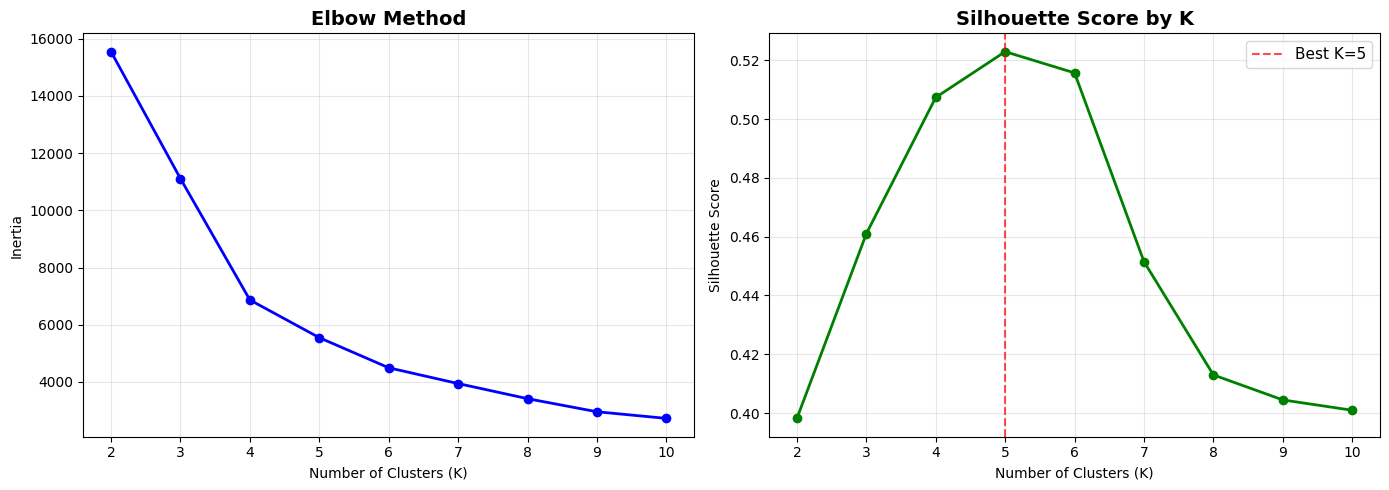


✅ Optimal K by Silhouette Score: 5


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('Number of Clusters (K)'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold'); axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2)
axes[1].set_xlabel('Number of Clusters (K)'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K', fontsize=14, fontweight='bold'); axes[1].grid(True, alpha=0.3)

optimal_k = list(K_range)[np.argmax(silhouette_scores)]
axes[1].axvline(x=optimal_k, color='red', linestyle='--', alpha=0.7, label=f'Best K={optimal_k}')
axes[1].legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n✅ Optimal K by Silhouette Score: {optimal_k}")

## Step 4: Run K-Means with K=5 & Profile Clusters

Based on the Elbow and Silhouette analysis, we fix **K=5** as the optimal number of segments.

**Final KMeans Hyperparameters:**

| Parameter | Value | Why this value? |
|-----------|-------|-----------------|
| `n_clusters` | 5 | Chosen from Step 3 — best balance of low inertia and high silhouette score. |
| `random_state` | 42 | Same seed as before for **consistency** with our evaluation runs. |
| `n_init` | 10 | 10 random initializations — the best result (lowest inertia) becomes the final model. Prevents poor convergence from a bad starting point. |

In [34]:
K = 5
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means with K={K} | Silhouette: {silhouette_score(X_scaled, df['cluster']):.4f}")
print(f"\nCluster sizes:")
print(df['cluster'].value_counts().sort_index())

K-Means with K=5 | Silhouette: 0.5229

Cluster sizes:
cluster
0    265
1    675
2    879
3    297
4    884
Name: count, dtype: int64


### Build Cluster Profiles

Aggregate key metrics per cluster to understand each segment's characteristics.

In [35]:
profile = df.groupby('cluster').agg({
    'avg_watch_hours': 'mean',
    'genre_diversity_score': 'mean',
    'subscription_type': lambda x: x.mode()[0],
    'days_active': 'mean',
    'completion_rate': 'mean',
    'device_primary': lambda x: x.mode()[0],
}).round(3)

profile

,avg_watch_hours,genre_diversity_score,subscription_type,days_active,completion_rate,device_primary
cluster,,,,,,
0,1.263,0.252,ad_supported,9.819,0.344,tablet
1,6.036,0.650,premium,25.594,0.785,desktop
2,5.223,0.629,premium,21.071,0.743,smart_tv
3,3.515,0.596,premium,10.983,0.654,tablet
4,1.929,0.315,ad_supported,16.577,0.417,mobile


### Assign Business Persona Names to Clusters

In [36]:
persona_names = {}
for cluster_id in range(K):
    c = profile.loc[cluster_id]
    if c['avg_watch_hours'] > 4 and c['days_active'] > 20:
        persona_names[cluster_id] = '🔥 Binge Watcher'
    elif c['avg_watch_hours'] < 2 and c['days_active'] < 12:
        persona_names[cluster_id] = '👀 Casual Browser'
    elif c['device_primary'] == 'mobile' and c['days_active'] > 15:
        persona_names[cluster_id] = '📱 Mobile Streamer'
    elif c['genre_diversity_score'] > 0.5 and c['subscription_type'] == 'premium':
        persona_names[cluster_id] = '💎 Premium Enthusiast'
    else:
        persona_names[cluster_id] = '📅 Weekend Warrior'

profile['persona'] = [persona_names[i] for i in range(K)]
print("=== Cluster Profiles ===")
print(profile.to_string())

=== Cluster Profiles ===
         avg_watch_hours  genre_diversity_score subscription_type  days_active  completion_rate device_primary               persona
cluster                                                                                                                             
0                  1.263                  0.252      ad_supported        9.819            0.344         tablet      👀 Casual Browser
1                  6.036                  0.650           premium       25.594            0.785        desktop       🔥 Binge Watcher
2                  5.223                  0.629           premium       21.071            0.743       smart_tv       🔥 Binge Watcher
3                  3.515                  0.596           premium       10.983            0.654         tablet  💎 Premium Enthusiast
4                  1.929                  0.315      ad_supported       16.577            0.417         mobile     📱 Mobile Streamer


## Step 5: PCA Visualization

PCA (Principal Component Analysis) reduces our 9-dimensional feature space to 2 dimensions so we can **visualize** the clusters on a scatter plot.

**PCA Hyperparameter:**

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `n_components` | 2 | Number of principal components to keep. We use **2** so we can plot clusters on a 2D chart (PC1 = x-axis, PC2 = y-axis). PCA finds the 2 directions that capture the **most variance** in the data. The `explained_variance_ratio_` tells us how much information is retained — ideally >50%. |

In [37]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA explained variance: {pca.explained_variance_ratio_}")
print(f"Total variance retained: {sum(pca.explained_variance_ratio_):.1%}")

PCA explained variance: [0.5019926  0.17477674]
Total variance retained: 67.7%


### Plot Clusters in 2D (PCA Projection)

C:\Users\dhimanmandal\AppData\Local\Temp\ipykernel_34676\1679212354.py:12: UserWarning: Glyph 128064 (\N{EYES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dhimanmandal\AppData\Local\Temp\ipykernel_34676\1679212354.py:12: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dhimanmandal\AppData\Local\Temp\ipykernel_34676\1679212354.py:12: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dhimanmandal\AppData\Local\Temp\ipykernel_34676\1679212354.py:12: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dhimanmandal\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128064 (\N{EYES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\dhimanmandal\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: User

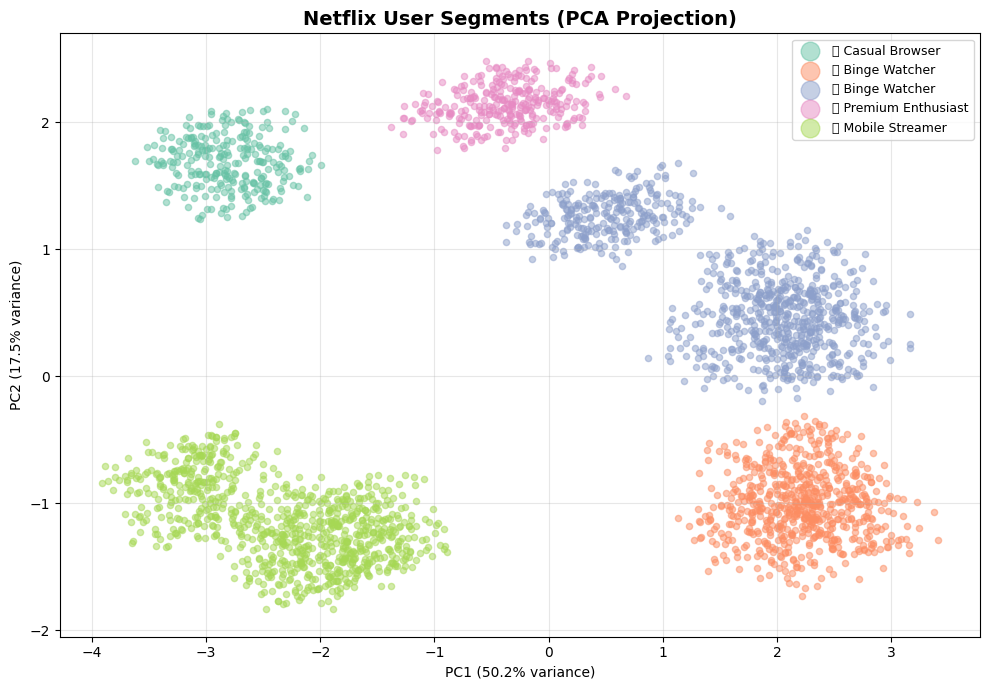

In [38]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.Set2.colors
for cluster_id in range(K):
    mask = df['cluster'] == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[colors[cluster_id]], label=persona_names[cluster_id], alpha=0.5, s=20)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Netflix User Segments (PCA Projection)', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, markerscale=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### How to Interpret the PCA Plot

The scatter plot above projects every user from **9 features** down to just **2 axes** (PC1 and PC2). Here's how to read it:

#### What are PC1 and PC2?
Each principal component is a **weighted combination of all original features**. For example:
- **PC1** might be driven mostly by `avg_watch_hours`, `days_active`, and `completion_rate` — think of it as an **"engagement intensity"** axis.
- **PC2** might be driven by `subscription_encoded`, `genre_diversity_score`, and device columns — think of it as a **"subscription & content breadth"** axis.

The loadings heatmap below shows the exact weights — **higher absolute value = that feature contributes more to that PC**.

#### Reading the Scatter Plot

| What you see | What it means |
|--------------|---------------|
| **Tight, well-separated clusters** | K-Means found clear segments — users within a cluster are similar, and clusters are distinct. |
| **Overlapping clusters** | Those segments share similar characteristics in the PCA-projected space; they may differ on features that PCA compressed away. |
| **Points far from their cluster center** | Borderline users who could belong to either segment — potential targets for personalized nudges. |
| **Movement along PC1 (left → right)** | Users change on the features that load heavily on PC1 (e.g., low engagement → high engagement). |
| **Movement along PC2 (bottom → top)** | Users change on the features that load heavily on PC2 (e.g., basic plan → premium plan). |

#### Important Caveat
PCA retains only a portion of the total variance (shown in axis labels). If total variance retained is low (e.g., <50%), the 2D plot is a **simplified view** — clusters may be better separated in the full 9D space than they appear here.

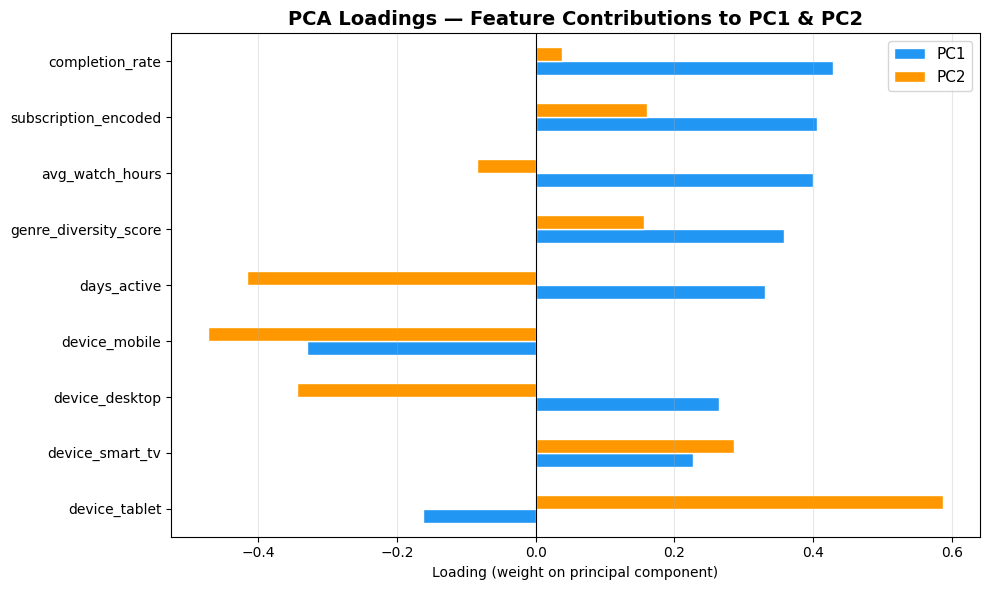


📊 Interpretation Guide:
  • Long bars = that feature strongly influences that PC direction
  • Positive loading = feature increases as you move right (PC1) or up (PC2)
  • Negative loading = feature increases as you move left (PC1) or down (PC2)

  → PC1 is most driven by: completion_rate
  → PC2 is most driven by: device_tablet


In [39]:
# PCA Loadings — which features drive PC1 and PC2?
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_names
)

# Sort by absolute contribution to PC1
loadings['abs_PC1'] = loadings['PC1'].abs()
loadings = loadings.sort_values('abs_PC1', ascending=True).drop(columns='abs_PC1')

fig, ax = plt.subplots(figsize=(10, 6))
loadings.plot(kind='barh', ax=ax, color=['#2196F3', '#FF9800'], edgecolor='white')
ax.set_xlabel('Loading (weight on principal component)')
ax.set_title('PCA Loadings — Feature Contributions to PC1 & PC2', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.grid(True, axis='x', alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\n📊 Interpretation Guide:")
print("  • Long bars = that feature strongly influences that PC direction")
print("  • Positive loading = feature increases as you move right (PC1) or up (PC2)")
print("  • Negative loading = feature increases as you move left (PC1) or down (PC2)")
top_pc1 = loadings['PC1'].abs().idxmax()
top_pc2 = loadings['PC2'].abs().idxmax()
print(f"\n  → PC1 is most driven by: {top_pc1}")
print(f"  → PC2 is most driven by: {top_pc2}")

## Step 6: Strategic Analysis — Segment Strategy & Revenue Impact

In [40]:
pricing = {'ad_supported': 6.99, 'basic': 9.99, 'standard': 15.49, 'premium': 22.99}
segment_ltv = df.groupby('cluster').apply(
    lambda x: pd.Series({
        'size': len(x),
        'pct': len(x) / len(df) * 100,
        'avg_watch_hrs': x['avg_watch_hours'].mean(),
        'avg_days_active': x['days_active'].mean(),
        'top_sub': x['subscription_type'].mode()[0],
        'avg_monthly_value': x['subscription_type'].map(pricing).mean(),
        'completion': x['completion_rate'].mean(),
        'churn_risk': 1 - x['days_active'].mean() / 30
    })
)
segment_ltv['persona'] = [persona_names[i] for i in range(K)]
segment_ltv['annual_revenue_per_user'] = segment_ltv['avg_monthly_value'] * 12
segment_ltv['est_ltv'] = segment_ltv['annual_revenue_per_user'] * (1 / (segment_ltv['churn_risk'] + 0.1))

segment_ltv

,size,pct,avg_watch_hrs,avg_days_active,top_sub,avg_monthly_value,completion,churn_risk,persona,annual_revenue_per_user,est_ltv
cluster,,,,,,,,,,,
0,265,8.833333,1.262792,9.818868,ad_supported,8.359811,0.344038,0.672704,👀 Casual Browser,100.317736,129.826795
1,675,22.500000,6.035926,25.594074,premium,21.101111,0.784874,0.146864,🔥 Binge Watcher,253.213333,1025.719144
2,879,29.300000,5.223288,21.070535,premium,20.592389,0.743129,0.297649,🔥 Binge Watcher,247.108669,621.424337
3,297,9.900000,3.514680,10.983165,premium,19.353636,0.654209,0.633895,💎 Premium Enthusiast,232.243636,316.453709
4,884,29.466667,1.929152,16.576923,ad_supported,10.031855,0.416516,0.447436,📱 Mobile Streamer,120.382262,219.902025


### Print Segment Strategy Brief

In [41]:
print("=" * 70)
print("SEGMENT STRATEGY BRIEF")
print("=" * 70)
for i in range(K):
    s = segment_ltv.loc[i]
    print(f"\n{'─'*50}")
    print(f"SEGMENT {i+1}: {s['persona']}")
    print(f"  Size: {s['size']:.0f} users ({s['pct']:.1f}%)")
    print(f"  Avg Watch: {s['avg_watch_hrs']:.1f} hrs/day | Active: {s['avg_days_active']:.0f} days/month")
    print(f"  Completion Rate: {s['completion']:.1%} | Churn Risk: {s['churn_risk']:.1%}")
    print(f"  Monthly Revenue: ${s['avg_monthly_value']:.2f} | Est. LTV: ${s['est_ltv']:.0f}")

SEGMENT STRATEGY BRIEF

──────────────────────────────────────────────────
SEGMENT 1: 👀 Casual Browser
  Size: 265 users (8.8%)
  Avg Watch: 1.3 hrs/day | Active: 10 days/month
  Completion Rate: 34.4% | Churn Risk: 67.3%
  Monthly Revenue: $8.36 | Est. LTV: $130

──────────────────────────────────────────────────
SEGMENT 2: 🔥 Binge Watcher
  Size: 675 users (22.5%)
  Avg Watch: 6.0 hrs/day | Active: 26 days/month
  Completion Rate: 78.5% | Churn Risk: 14.7%
  Monthly Revenue: $21.10 | Est. LTV: $1026

──────────────────────────────────────────────────
SEGMENT 3: 🔥 Binge Watcher
  Size: 879 users (29.3%)
  Avg Watch: 5.2 hrs/day | Active: 21 days/month
  Completion Rate: 74.3% | Churn Risk: 29.8%
  Monthly Revenue: $20.59 | Est. LTV: $621

──────────────────────────────────────────────────
SEGMENT 4: 💎 Premium Enthusiast
  Size: 297 users (9.9%)
  Avg Watch: 3.5 hrs/day | Active: 11 days/month
  Completion Rate: 65.4% | Churn Risk: 63.4%
  Monthly Revenue: $19.35 | Est. LTV: $316

────

### Retention Impact — Revenue Saved by Reducing Churn

In [42]:
best = segment_ltv.nlargest(1, 'est_ltv').iloc[0]
worst = segment_ltv.nlargest(1, 'churn_risk').iloc[0]
print(f"💎 HIGHEST LTV: {best['persona']} (${best['est_ltv']:.0f})")
print(f"⚠️ HIGHEST CHURN RISK: {worst['persona']} ({worst['churn_risk']:.1%})")

at_risk_users = worst['size'] * worst['churn_risk']
saved_users = at_risk_users * 0.05
revenue_saved = saved_users * worst['annual_revenue_per_user']
print(f"\n💰 RETENTION IMPROVEMENT (5% in at-risk segment):")
print(f"   Users saved: {saved_users:.0f}")
print(f"   Annual revenue saved: ${revenue_saved:,.0f}")
print(f"   At Netflix scale (247M users): ${revenue_saved * (247_000_000 / len(df)):,.0f}")

💎 HIGHEST LTV: 🔥 Binge Watcher ($1026)
⚠️ HIGHEST CHURN RISK: 👀 Casual Browser (67.3%)

💰 RETENTION IMPROVEMENT (5% in at-risk segment):
   Users saved: 9
   Annual revenue saved: $894
   At Netflix scale (247M users): $73,619,619
